Opening video: /Users/ayraj/Desktop/video_captioning/TrainValVideo/video2963.mp4
Total frames in video: 275
Extracting frame numbers: [  0  39  78 117 156 195 234 274]
Displaying extracted frames...


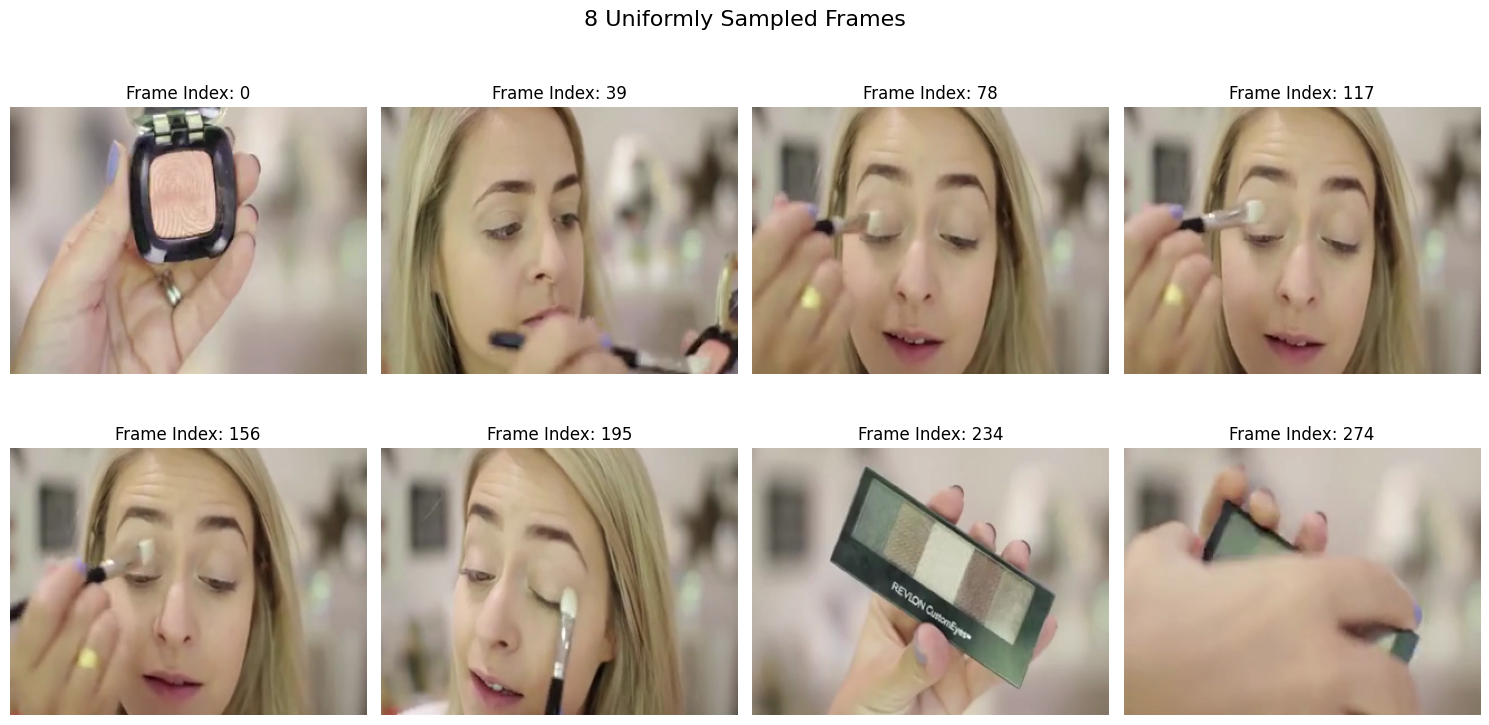

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup Path
# ==========================================
# Put the path to the MP4 video you want to test here:
VIDEO_PATH = "/TrainValVideo/video2963.mp4" 

print(f"Opening video: {VIDEO_PATH}")

# ==========================================
# 2. Extract Frames
# ==========================================
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if total_frames == 0:
    print("Error: Could not read the video file. Check the path!")
    exit()

print(f"Total frames in video: {total_frames}")

# Calculate exactly 8 evenly spaced frame indices
frame_indices = np.linspace(0, total_frames - 1, 8, dtype=int)
print(f"Extracting frame numbers: {frame_indices}")

frames_rgb = []

for idx in frame_indices:
    # Jump exactly to the specific frame number
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    
    if ret:
        # OpenCV reads in BGR format, but we need RGB to display colors correctly
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames_rgb.append(frame_rgb)

cap.release()

# ==========================================
# 3. Display the Frames in a Grid
# ==========================================
print("Displaying extracted frames...")

# Create a figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle("8 Uniformly Sampled Frames", fontsize=16)

# Flatten the axes array to easily loop through it
axes = axes.flatten()

for i, (frame, ax) in enumerate(zip(frames_rgb, axes)):
    ax.imshow(frame)
    ax.set_title(f"Frame Index: {frame_indices[i]}")
    ax.axis("off") # Hides the x/y axis numbers for a cleaner look

# Adjust layout so they don't overlap, and show the window!
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
from transformers import BlipProcessor, BlipForConditionalGeneration



MODEL_PATH = "/blip_video_model_2"

NPZ_FILE = "/final_frames_v2/video2963.npz" 

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"


# Load BLIP Model & Processor

print(f"Loading Fine-Tuned BLIP model from {MODEL_PATH}...")
processor = BlipProcessor.from_pretrained(MODEL_PATH)
model = BlipForConditionalGeneration.from_pretrained(MODEL_PATH)

model.to(DEVICE)
model.eval()


# Load & Process the NPZ File

print(f"Loading frames from {NPZ_FILE}...")
data = np.load(NPZ_FILE)

# Handle the array depending on how it was saved (usually 'video' in your MSR-VTT dataset)
if 'video' in data:
    video_array = data['video']
elif 'frames' in data:
    video_array = data['frames']
else:
    # If the key is something else, just grab the first array in the file
    video_array = data[data.files[0]]

print("Original array shape:", video_array.shape) # Usually (3, 8, 224, 224)

# BLIP Trick: Extract the exact middle frame to capture the main action
middle_idx = video_array.shape[1] // 2
frame = video_array[:, middle_idx, :, :] # New shape: (3, 224, 224)

# Convert from (Channels, Height, Width) to (Height, Width, Channels) for the processor
frame = np.transpose(frame, (1, 2, 0))

# Ensure the colors are properly scaled to 0-255 for the processor
if frame.max() <= 1.0:
    frame = (frame * 255).astype(np.uint8)
else:
    frame = frame.astype(np.uint8)

print("Processed middle frame shape:", frame.shape) # Should be (224, 224, 3)

# Pass the single frame directly to the processor
inputs = processor(images=frame, return_tensors="pt").to(DEVICE)


# 4. Generate the Caption
print("Generating caption...")
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_length=30,
        num_beams=5,             # Explores the 5 best possible sentences
        early_stopping=True,
        no_repeat_ngram_size=2   # Prevents repeating words!
    )

# Decode the tokens back into an English sentence
caption = processor.decode(output_ids[0], skip_special_tokens=True)

print("\n" + "="*40)
print("🎥 Generated Caption:", caption)
print("="*40 + "\n")

Loading Fine-Tuned BLIP model from /Users/ayraj/Desktop/video_captioning/blip_video_model_2...


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 7712.40it/s]
The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading frames from /Users/ayraj/Desktop/video_captioning/final_frames_v2/video2963.npz...
Original array shape: (3, 8, 224, 224)
Processed middle frame shape: (224, 224, 3)
Generating caption...

🎥 Generated Caption: a woman is showing how to do eye makeup

